---
# Understanding seeding

I set a seed at the beginning because quite a few parts of my experiment involve randomness. 

from scikit learn random state "Determines random number generation for centroid initialization. Use an int to make the randomness deterministic". so we set a seed at the start using

The autoencoder initialises its weights randomly. NumPy operations like noise injection use random numbers. Without fixing the seed, each run produces slightly different results 

I ran into this problem when I first started testing my outcomes and realised they were changing every time. I thought this meant I had a massive overfitting problem but it was just because i was re running the training each time with a new random number.



In [2]:

import random
import numpy as np
import pandas as pd

# First choose a fixed seed. this number doesnt matter just needs to be consistent
SEED = 42

# set the seed for all the libraries that we use that involve randomness
random.seed(SEED)
np.random.seed(SEED)

# Read data
df_avg = pd.read_csv('../data/processed/avg_cleaned_feature_matrix.csv')


---
# Something new

kmeans++ to make sure the clusters initialise somewhat far from one another. Didn't change much for my data

---
# understanding the kmeans algorithm in detail

In [7]:

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Assigns a kmeans object using the seed we set, a number of clusters k and a number of initialisations to perfrom.
# We keep the best result from the 10 initialisations
km = KMeans(n_clusters=6, random_state=SEED, n_init=10)

# Fit the model and predict the cluster labels for each country
# Two things happen here: the model is fit to the data and then does the kmeans algorithm to find the clusters then it predicts the ckluster labesl for each country
# This returns an array of cluster labels for each country, which we store in km_labels
km_labels = km.fit_predict(df_avg.drop(columns=['Name', 'country_code']))

# Calculate the silhouette score by comparing the cluster labels to the original data 
# this is a measure of how well the clusters are separated and how cohesive the clusters are. A higher silhouette score indicates better clustering.

sil_score = silhouette_score(df_avg.drop(columns=['Name', 'country_code']), km_labels)

print(f"KMeans Silhouette Score: {sil_score:.4f}\n")
# Print the countries in each cluster
for i in range(6):
    countries = df_avg[km_labels == i]['Name'].sort_values().tolist()
    print(f"  Archetype {i} ({len(countries)}): {', '.join(countries)}")

KMeans Silhouette Score: 0.1864

  Archetype 0 (15): Austria, Belgium, France, Germany, Greece, Hungary, Italy, Latvia, Lithuania, Netherlands, Portugal, Slovakia, Spain, Switzerland, United Kingdom
  Archetype 1 (7): Brazil, India, Indonesia, Peru, Philippines, Turkey, Viet Nam
  Archetype 2 (7): Canada, Finland, Iceland, Ireland, Luxembourg, Norway, Sweden
  Archetype 3 (2): Denmark, New Zealand
  Archetype 4 (7): Argentina, Chile, Colombia, Japan, Mexico, Slovenia, South Africa
  Archetype 5 (11): Australia, China, Czech Republic, Estonia, Israel, Korea, Republic of, Poland, Russian Federation, Saudi Arabia, Singapore, United States


---
# My Understanding of this outcome

It isn't a great score but that's not necessarily a bad thing. the numbers can range from -1 to 1 so we're not in the negatives which is a good thing.
If I were to run pca on this then it may improve the score but that is just because we reduce to 2 dimensions which actually means its a whole other score the best way to improve the score is to try out dif parameters and I know that if I run an ae before kmeans it improves drastically

---
# Going to visualise with pca using code from scikit learn

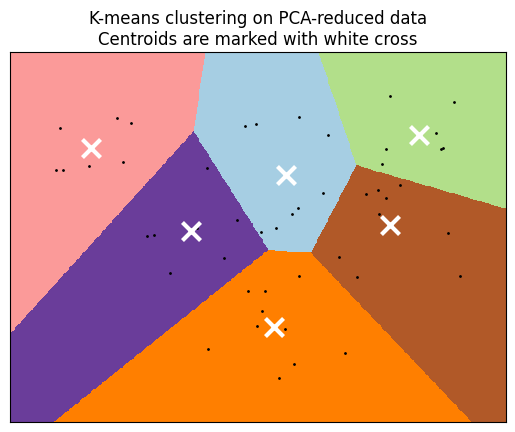

In [10]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

reduced_data = PCA(n_components=2).fit_transform(df_avg.drop(columns=['Name', 'country_code']))
km.fit(reduced_data)

# Step size of the mesh. Decrease to increase the quality of the VQ.
h = 0.02  # point in the mesh [x_min, x_max]x[y_min, y_max].

# Plot the decision boundary. For that, we will assign a color to each
x_min, x_max = reduced_data[:, 0].min() - 1, reduced_data[:, 0].max() + 1
y_min, y_max = reduced_data[:, 1].min() - 1, reduced_data[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Obtain labels for each point in mesh. Use last trained model.
Z = km.predict(np.c_[xx.ravel(), yy.ravel()])

# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.figure(1)
plt.clf()
plt.imshow(
    Z,
    interpolation="nearest",
    extent=(xx.min(), xx.max(), yy.min(), yy.max()),
    cmap=plt.cm.Paired,
    aspect="auto",
    origin="lower",
)

plt.plot(reduced_data[:, 0], reduced_data[:, 1], "k.", markersize=2)
# Plot the centroids as a white X
centroids = km.cluster_centers_
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="x",
    s=169,
    linewidths=3,
    color="w",
    zorder=10,
)
plt.title(
    "K-means clustering on PCA-reduced data\n"
    "Centroids are marked with white cross"
)
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.xticks(())
plt.yticks(())
plt.show()



# Important note about the PCA visualisation

Using PCA to reduce the dimensionality of the data to 2 dimensions for visualization purposes only
It doesnt change the actual clustering results, it just allows me to visualize the clusters in 2D.
It isn't a good idea to use PCA for dimensionality reduction before clustering because it can distort the distances between points and therefore affect the clustering results. 
PCA is a linear transformation that projects the data onto a lower-dimensional space, which can lead to loss of information and changes in the structure of the data.
This can result in clusters that are not well separated or that do not reflect the true underlying structure of the data. 
It is generally better to perform clustering on the original high-dimensional data rather than on a reduced-dimensional representation.

---
# Then I moved on to hierarchical which I won't go into detail

builds nested clusters by merging or splitting them successively. This hierarchy of clusters is represented as a tree (or dendrogram).

---
# Then tried out DBSCAN which was quite a fail... but the outliers were interesting

DBSCAN views clusters as areas of high density separated by areas of low density. Due to this rather generic view, clusters found by DBSCAN can be any shape, as opposed to k-means which assumes that clusters are convex shaped.

---
# Then began using an autoencoder which drastically helped
